# Get the data

In [56]:
import pandas as pd

df = pd.read_csv('../../../datasets/drug200.csv')


# Geral analyzes

In [57]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [58]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [59]:
df.dtypes

Age              int64
Sex                str
BP                 str
Cholesterol        str
Na_to_K        float64
Drug               str
dtype: object

In [60]:
object_features =['Sex', "BP", "Cholesterol", "Drug"]
for feature in object_features:
    print(f"Feature: {feature}, values: {df[feature].value_counts()}\n\n")

Feature: Sex, values: Sex
M    104
F     96
Name: count, dtype: int64


Feature: BP, values: BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64


Feature: Cholesterol, values: Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64


Feature: Drug, values: Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64




# Data Cleaning

In [61]:
print(f"Missing values in dataframe: \n{df.isnull().sum()}")

Missing values in dataframe: 
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


In [62]:
print(f"Duplicated values: {df.duplicated().sum().sum()}")

Duplicated values: 0


In [63]:
numeric_features = ["Age", 'Na_to_K']

for feature in numeric_features:
    if (df[feature].min() < 0):
        print(f"Feature: {feature}, have negative values")
    else:
        print(f"Feature: {feature} don't have negative values")

Feature: Age don't have negative values
Feature: Na_to_K don't have negative values


# Data Engineering

In [64]:
# Sex -> Binary
# BP -> Ordinal 
#  Cholesterol -> Ordinal (how it's only 2 values we can use as binary too)
# Target -> N_classe


from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

print(f"Dtypes before ENCODER: {df.dtypes}\n\n\n")

for feature in object_features:
    if feature == "Drug":
        encoder = LabelEncoder()
        df[feature] = encoder.fit_transform(df[feature])
    elif feature == 'BP':
        encoder = OrdinalEncoder()
        df[feature] = encoder.fit_transform(df[[feature]])
    else:
        encoder = OneHotEncoder(sparse_output=False)
        df[feature] = encoder.fit_transform(df[[feature]])

print(f"Dtypes after ENCODER: {df.dtypes}")

Dtypes before ENCODER: Age              int64
Sex                str
BP                 str
Cholesterol        str
Na_to_K        float64
Drug               str
dtype: object



Dtypes after ENCODER: Age              int64
Sex            float64
BP             float64
Cholesterol    float64
Na_to_K        float64
Drug             int64
dtype: object


# Data tunning

In [65]:
# How we have low feature DATA TUNNING ISN'T NECESSARY (JUST IF THE MODEL CAN'T BE GOOD)


# Split the data

In [66]:
X = df.drop('Drug', axis = 1)
y = df["Drug"]

print(f"Shapes of X: {X.shape}, Y: {y.shape}")

Shapes of X: (200, 5), Y: (200,)


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify= y)

# Train and metrics

In [68]:
import warnings
warnings.simplefilter("ignore")

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

models = [DecisionTreeClassifier(), RandomForestClassifier(), AdaBoostClassifier(), XGBClassifier(), LGBMClassifier(verbose = -1), KNeighborsClassifier()]

----------------------------------------
Model: DecisionTreeClassifier
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:0.975 | F1: 0.985 | Precision: 0.989 | Recall: 0.982 | 
Confusion Matriz:


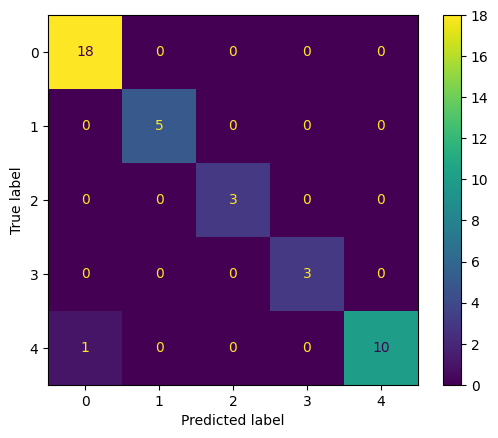

Features analyzes: 
Feature: Age, importance in the model: 9.50%
Feature: Sex, importance in the model: 0.00%
Feature: BP, importance in the model: 31.50%
Feature: Cholesterol, importance in the model: 7.50%
Feature: Na_to_K, importance in the model: 49.00%
----------------------------------------
Model: RandomForestClassifier
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:0.975 | F1: 0.985 | Precision: 0.989 | Recall: 0.982 | 
Confusion Matriz:


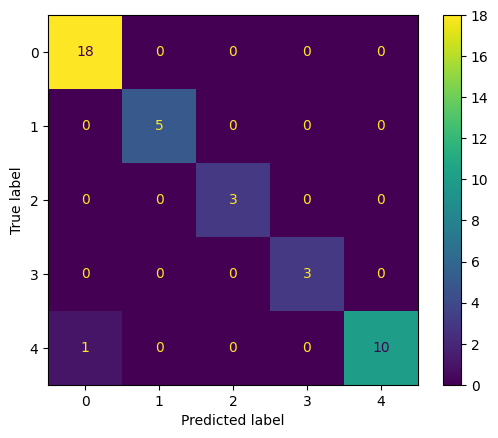

Features analyzes: 
Feature: Age, importance in the model: 9.50%
Feature: Sex, importance in the model: 0.00%
Feature: BP, importance in the model: 31.50%
Feature: Cholesterol, importance in the model: 7.50%
Feature: Na_to_K, importance in the model: 49.00%
----------------------------------------
Model: AdaBoostClassifier
Train Metrics: Accuracy:0.838 | F1: 0.521 | Precision: 0.470 | Recall: 0.600|
Test Metrics: Accuracy:0.825 | F1: 0.515 | Precision: 0.468 | Recall: 0.582 | 
Confusion Matriz:


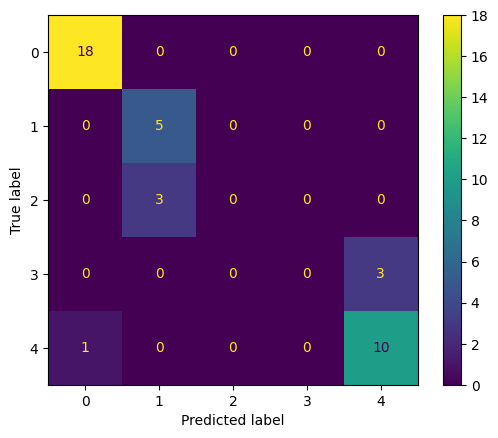

Features analyzes: 
Feature: Age, importance in the model: 0.00%
Feature: Sex, importance in the model: 0.00%
Feature: BP, importance in the model: 17.75%
Feature: Cholesterol, importance in the model: 0.00%
Feature: Na_to_K, importance in the model: 41.25%
----------------------------------------
Model: XGBClassifier
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:0.975 | F1: 0.949 | Precision: 0.950 | Recall: 0.960 | 
Confusion Matriz:


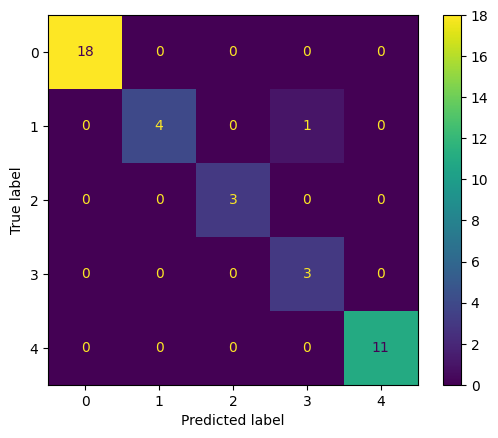

Features analyzes: 
Feature: Age, importance in the model: 7.00%
Feature: Sex, importance in the model: 0.00%
Feature: BP, importance in the model: 31.25%
Feature: Cholesterol, importance in the model: 8.75%
Feature: Na_to_K, importance in the model: 50.00%
----------------------------------------
Model: LGBMClassifier
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:0.950 | F1: 0.934 | Precision: 0.939 | Recall: 0.942 | 
Confusion Matriz:


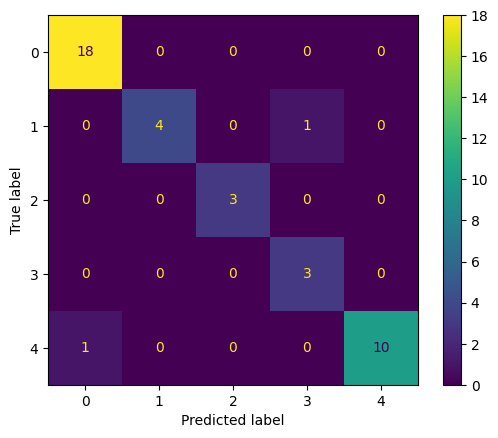

Features analyzes: 
Feature: Age, importance in the model: 7.00%
Feature: Sex, importance in the model: 0.00%
Feature: BP, importance in the model: 30.25%
Feature: Cholesterol, importance in the model: 7.50%
Feature: Na_to_K, importance in the model: 48.25%
----------------------------------------
Model: KNeighborsClassifier
Train Metrics: Accuracy:0.875 | F1: 0.840 | Precision: 0.841 | Recall: 0.843|
Test Metrics: Accuracy:0.650 | F1: 0.620 | Precision: 0.658 | Recall: 0.606 | 
Confusion Matriz:


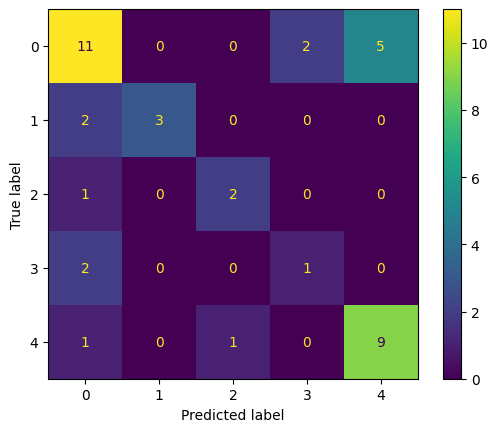

Features analyzes: 
Feature: Age, importance in the model: 5.25%
Feature: Sex, importance in the model: -13.50%
Feature: BP, importance in the model: 16.75%
Feature: Cholesterol, importance in the model: -3.00%
Feature: Na_to_K, importance in the model: 20.75%


In [76]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

for model in models:
    print('----------------------------------------')
    print(f"Model: {model.__class__.__name__}")

    pipe = Pipeline(
        steps=[
            ("Scaler", StandardScaler()),
            ("Model", model)
        ]
    )

    # TRAIN THE MODEL
    pipe.fit(X_train, y_train)

    # See if overfitting (predict the train pipe)
    y_preds_train = pipe.predict(X_train)
    accuracy = accuracy_score(y_train, y_preds_train)
    f1 = f1_score(y_train, y_preds_train, average = 'macro')
    precision = precision_score(y_train, y_preds_train, average = 'macro')
    recall = recall_score(y_train, y_preds_train, average = 'macro')
    print(f"Train Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}|")

    # See the metrics (test set)
    y_preds_test = pipe.predict(X_test)
    accuracy = accuracy_score(y_test, y_preds_test)
    f1 = f1_score(y_test, y_preds_test, average = 'macro')
    precision = precision_score(y_test, y_preds_test, average = 'macro')
    recall = recall_score(y_test, y_preds_test, average = 'macro')
    confusion_m = ConfusionMatrixDisplay.from_predictions(y_test, y_preds_test)
    print(f"Test Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | \nConfusion Matriz:")
    plt.show()

    # See the features importances
    print(f"Features analyzes: ")
    permutation = permutation_importance(pipe, X_test, y_test, random_state = 42, n_repeats= 10)
    for feature, importance in zip(X.columns, permutation.importances_mean):
        print(f"Feature: {feature}, importance in the model: {importance*100:.2f}%")